In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import os

import clickhouse_connect

# Show all rows
pd.set_option("display.max_rows", None)

# Show all columns
pd.set_option("display.max_columns", None)

# Make sure wide DataFrames don't wrap
pd.set_option("display.width", None)

# Show the full content of each column (no '...')
pd.set_option("display.max_colwidth", None)

In [2]:
client = clickhouse_connect.get_client(
    host='yaujulxk39.eastus2.azure.clickhouse.cloud',      # or server IP
    port=8443,             # HTTP port (default)
    username='default',
    password='~gZjRLjjOJh1i',
    database='Competitive_Analysis'
)


In [3]:
# ---- Query ----
df_hum_hist = client.query_df("""
    SELECT *
    FROM Competitive_Analysis.DRGHistoricalReviewInformation
    WHERE Client = 'Hum'
""")
df_hum_hist.shape

(76355, 291)

In [4]:
# -------------------------------------------------
# Initial shape of the dataset
# -------------------------------------------------
df_hum = df_hum_hist.copy()

print(df_hum.shape)  

df_hum = df_hum[df_hum['InitialDenialType'] == 'Substantive']
print(df_hum.shape) 

# -------------------------------------------------
# Identify valid Group_Type values
# -------------------------------------------------

group_type_unique = df_hum['Group_Type'].dropna().unique()
print(group_type_unique) 

# -------------------------------------------------
# Filter dataset to only valid Group_Type rows
# Use .copy() to avoid SettingWithCopyWarning
# -------------------------------------------------
df_hum_group_type = df_hum[df_hum['Group_Type'].isin(group_type_unique)].copy()
print(df_hum_group_type.shape) 

# -------------------------------------------------
# Calculate ADRG length
# -------------------------------------------------
df_hum_group_type.loc[:, 'len_adrg'] = (
    df_hum_group_type['ADRG'].astype(str).str.len()
)

print(df_hum_group_type['len_adrg'].value_counts())
print(df_hum_group_type['Group_Type'].value_counts())

# -------------------------------------------------
# Remove invalid DRG / Group_Type combinations
#   1) Group_Type = '01' and ADRG length = 4
#   2) Group_Type = '10' and ADRG length = 3
# -------------------------------------------------
mask_remove = (
    ((df_hum_group_type['Group_Type'] == '01') & (df_hum_group_type['len_adrg'] == 4)) |
    ((df_hum_group_type['Group_Type'] == '10') & (df_hum_group_type['len_adrg'] == 3))
)

df_hum_drg_rem = df_hum_group_type.loc[~mask_remove].copy()
print(df_hum_drg_rem.shape)

# -------------------------------------------------
# Create a copy of InitialDeterminationDate
# -------------------------------------------------
df_hum_drg_rem.loc[:, 'InitialDeterminationDate_copy'] = (
    df_hum_drg_rem['InitialDeterminationDate']
)

print(
    df_hum_drg_rem['Control_ID']
    .value_counts()
    .sort_values(ascending=False)
    .head()
)

# -------------------------------------------------
# Convert date column to datetime
# -------------------------------------------------
df_hum_drg_rem.loc[:, 'InitialDeterminationDate_copy'] = pd.to_datetime(
    df_hum_drg_rem['InitialDeterminationDate_copy'],
    errors='coerce'
)

# -------------------------------------------------
# Keep latest record per Control_ID
# -------------------------------------------------
df_sorted = df_hum_drg_rem.sort_values(
    'InitialDeterminationDate_copy',
    ascending=False
)

df_hum_latest = df_sorted.drop_duplicates(
    subset='Control_ID',
    keep='first'
).copy()

print(df_hum_latest.shape)

# -------------------------------------------------
# Normalize string columns
# -------------------------------------------------
df_hum_latest.loc[:, 'ADRG'] = (
    df_hum_latest['ADRG'].astype(str).str.strip()
)

df_hum_latest.loc[:, 'PRIM_DX'] = (
    df_hum_latest['PRIM_DX'].astype(str).str.strip().str.upper()
)

df_hum_latest.loc[:, 'InitialDeterminationStatus'] = (
    df_hum_latest['InitialDeterminationStatus']
    .astype(str)
    .str.strip()
    .str.upper()
)

# -------------------------------------------------
# Clean numeric fields
# -------------------------------------------------
df_hum_latest.loc[:, 'IDSavings'] = (
    pd.to_numeric(df_hum_latest['IDSavings'], errors='coerce').fillna(0)
)

df_hum_latest.loc[:, 'LOS'] = (
    pd.to_numeric(df_hum_latest['LOS'], errors='coerce').fillna(0)
)

df_hum_latest.loc[:, 'AGE'] = (
    pd.to_numeric(df_hum_latest['AGE'], errors='coerce')
)

# -------------------------------------------------
# Validate AGE values
# -------------------------------------------------
max_age = df_hum_latest['AGE'].max()

df_hum_latest = df_hum_latest[(
    df_hum_latest['AGE'].between(0, max_age))
].copy()
df_hum_latest.loc[:, 'AGE'] = df_hum_latest['AGE'].astype('Int64')
print(df_hum_latest.shape)

# -------------------------------------------------
# Validate LOS values
# -------------------------------------------------
df_hum_latest.loc[:, 'LOS'] = (
    df_hum_latest['LOS'].astype('Int64')
)

df_hum_latest = df_hum_latest[(df_hum_latest['LOS'] >= 0)].copy()
print(df_hum_latest.shape)

# -------------------------------------------------
# Remove extreme savings outliers
# -------------------------------------------------
df_hum_latest = df_hum_latest[
    df_hum_latest['IDSavings'] < 650000
].reset_index(drop=True)

print(df_hum_latest.shape)

# Date only
df_hum_latest['InitialDeterminationDate_date'] = (
    df_hum_latest['InitialDeterminationDate'].dt.date
)

# Year
df_hum_latest['InitialDetermination_Year'] = (
    df_hum_latest['InitialDeterminationDate'].dt.year
)

df_hum_latest["InitialDeterminationDate_date"] = pd.to_datetime(
    df_hum_latest["InitialDeterminationDate_date"],
    errors="coerce"   # handles bad / empty values safely
)


df_hum_latest['InitialDeterminationStatus_Flag'] = (
    df_hum_latest['InitialDeterminationStatus']
    .str.strip()
    .str.upper()
    .map({
        'APPROVED': 0,
        'DENIED': 1
    })
)


df_hum_latest.shape

(76355, 291)
(76355, 291)
<StringArray>
['01', '10']
Length: 2, dtype: string
(76351, 291)
len_adrg
3    75215
4     1136
Name: count, dtype: int64
Group_Type
01    75214
10     1137
Name: count, dtype: Int64
(76340, 292)
Control_ID
HUPTMR-40741    1
HUPTMR-9633     1
HUPTMR-51303    1
HUPTMR-9989     1
HUPTMR-10906    1
Name: count, dtype: Int64
(76340, 293)
(76339, 293)
(76337, 293)
(76337, 293)


(76337, 296)

In [5]:
df_hum_ms_drg = df_hum_latest[df_hum_latest['Group_Type']=='01']
print(df_hum_ms_drg.shape)

df_hum_ms_drg['len_adrg'].value_counts()

(75206, 296)


len_adrg
3    75206
Name: count, dtype: int64

In [39]:
df = df_hum_ms_drg.copy()

adx_cols = [f"A_DX{i}" for i in range(2, 26)]
apx_cols = [f"A_PX{i}" for i in range(1, 26)]
bdx_cols = [f"B_DX{i}" for i in range(2, 26)]
bpx_cols = [f"B_PX{i}" for i in range(1, 26)]

df["A_DX_List"] = df[adx_cols].values.tolist()
df["A_PX_List"] = df[apx_cols].values.tolist()
df["B_DX_List"] = df[bdx_cols].values.tolist()
df["B_PX_List"] = df[bpx_cols].values.tolist()

# Convert to sorted comma separated values
df["A_DX_List"] = df["A_DX_List"].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])))
df["A_PX_List"] = df["A_PX_List"].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])))
df["B_DX_List"] = df["B_DX_List"].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])))
df["B_PX_List"] = df["B_PX_List"].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])))


def clean_sdx_list(val):
    if pd.isna(val) or val == "":
        return ""
    
    lst = val.split(",")  # split comma-separated values
    cleaned = []
    
    for item in lst:
        item = str(item).upper().strip()       # normalize
        item = item.replace("- MCC", "")       # remove MCC
        item = item.replace("- CC", "")        # remove CC
        item = item.replace("MCC", "")         # safety
        item = item.replace("CC", "")          # safety
        item = item.strip().replace("-", "")   # final cleanup
        cleaned.append(item)
    
    return ",".join(sorted(cleaned))  # sort again and join

df["A_DX_List_Clean"] = df["A_DX_List"].apply(clean_sdx_list)
df["B_DX_List_Clean"] = df["B_DX_List"].apply(clean_sdx_list)

mccandcclist_df = pd.read_excel(r"C:\Arun_MIX\MCCCCList.xlsx")
mccandcclist_df['ICDCode'] = (
    mccandcclist_df['ICDCode']
    .astype(str)
    .str.strip()
    .str.upper()
)
mccandcclist = dict(zip(mccandcclist_df['ICDCode'], mccandcclist_df['MCCorCC']))
print(f"✅ Loaded MCC/CC list with {len(mccandcclist)} entries.")

def map_sdx_types(icd_string, lookup_dict):

    if pd.isna(icd_string) or icd_string == "":
        return []

    icd_list = icd_string.split(",")

    cleaned_list = []
    for code in icd_list:
        code_clean = str(code).strip().upper()
        tag = lookup_dict.get(code_clean, "")
        cleaned_list.append(f"{code_clean} - {tag}")

    return cleaned_list


df['A_DX_Type_list'] = df['A_DX_List_Clean'].apply(lambda x: map_sdx_types(x, mccandcclist))
df['B_DX_Type_list'] = df['B_DX_List_Clean'].apply(lambda x: map_sdx_types(x, mccandcclist))


def split_dx_types(dx_list):

    mcc = [x.split(" - ")[0] for x in dx_list if "- MCC" in x]
    cc = [x.split(" - ")[0] for x in dx_list if "- CC" in x]
    general = [x.split(" - ")[0] for x in dx_list if "- MCC" not in x and "- CC" not in x]

    return pd.Series({
        "A_DX_MCC_Set": ",".join(sorted(mcc)),
        "A_DX_CC_Set": ",".join(sorted(cc)),
        "A_DX_General_Set": ",".join(sorted(general)),
        "A_DX_MCC_Count": len(mcc),
        "A_DX_CC_Count": len(cc),
        "A_DX_General_Count": len(general)
    })


df[[
    "A_DX_MCC_Set",
    "A_DX_CC_Set",
    "A_DX_General_Set",
    "A_DX_MCC_Count",
    "A_DX_CC_Count",
    "A_DX_General_Count"
]] = df["A_DX_Type_list"].apply(split_dx_types)

df.head(1)



✅ Loaded MCC/CC list with 17913 entries.


,Payor,claimid,Client,Control_ID,Claim_Number,PaymentType,Group_Type,Payments,Tax_ID,Provider_ID,HospitalName,LOS,DISP_Code,ADRG,DischargeYear,DischargeMonth,AGE,A_CCCount,A_MCCCount,B_CCCount,B_MCCCount,LOB,MRREQ,MRREC,PRIM_DX,A_DX2,A_DX3,A_DX4,A_DX5,A_DX6,A_DX7,A_DX8,A_DX9,A_DX10,A_DX11,A_DX12,A_DX13,A_DX14,A_DX15,A_DX16,A_DX17,A_DX18,A_DX19,A_DX20,A_DX21,A_DX22,A_DX23,A_DX24,A_DX25,A_POA,A_POA2,A_POA3,A_POA4,A_POA5,A_POA6,A_POA7,A_POA8,A_POA9,A_POA10,A_POA11,A_POA12,A_POA13,A_POA14,A_POA15,A_POA16,A_POA17,A_POA18,A_POA19,A_POA20,A_POA21,A_POA22,A_POA23,A_POA24,A_POA25,A_PX1,A_PX2,A_PX3,A_PX4,A_PX5,A_PX6,A_PX7,A_PX8,A_PX9,A_PX10,A_PX11,A_PX12,A_PX13,A_PX14,A_PX15,A_PX16,A_PX17,A_PX18,A_PX19,A_PX20,A_PX21,A_PX22,A_PX23,A_PX24,A_PX25,B_DISPCode,B_DenialCode,B_DRG,B_PRIMDX,B_DX2,B_DX3,B_DX4,B_DX5,B_DX6,B_DX7,B_DX8,B_DX9,B_DX10,B_DX11,B_DX12,B_DX13,B_DX14,B_DX15,B_DX16,B_DX17,B_DX18,B_DX19,B_DX20,B_DX21,B_DX22,B_DX23,B_DX24,B_DX25,B_POA,B_POA2,B_POA3,B_POA4,B_POA5,B_POA6,B_POA7,B_POA8,B_POA9,B_POA10,B_POA11,B_POA12,B_POA13,B_POA14,B_POA15,B_POA16,B_POA17,B_POA18,B_POA19,B_POA20,B_POA21,B_POA22,B_POA23,B_POA24,B_POA25,B_PX1,B_PX2,B_PX3,B_PX4,B_PX5,B_PX6,B_PX7,B_PX8,B_PX9,B_PX10,B_PX11,B_PX12,B_PX13,B_PX14,B_PX15,B_PX16,B_PX17,B_PX18,B_PX19,B_PX20,B_PX21,B_PX22,B_PX23,B_PX24,B_PX25,A_PRIMDX_Desc,A_DX2_Desc,A_DX3_Desc,A_DX4_Desc,A_DX5_Desc,A_DX6_Desc,A_DX7_Desc,A_DX8_Desc,A_DX9_Desc,A_DX10_Desc,A_DX11_Desc,A_DX12_Desc,A_DX13_Desc,A_DX14_Desc,A_DX15_Desc,A_DX16_Desc,A_DX17_Desc,A_DX18_Desc,A_DX19_Desc,A_DX20_Desc,A_DX21_Desc,A_DX22_Desc,A_DX23_Desc,A_DX24_Desc,A_DX25_Desc,A_PX1_Desc,A_PX2_Desc,A_PX3_Desc,A_PX4_Desc,A_PX5_Desc,A_PX6_Desc,A_PX7_Desc,A_PX8_Desc,A_PX9_Desc,A_PX10_Desc,A_PX11_Desc,A_PX12_Desc,A_PX13_Desc,A_PX14_Desc,A_PX15_Desc,A_PX16_Desc,A_PX17_Desc,A_PX18_Desc,A_PX19_Desc,A_PX20_Desc,A_PX21_Desc,A_PX22_Desc,A_PX23_Desc,A_PX24_Desc,A_PX25_Desc,B_PRIMDX_Desc,B_DX2_Desc,B_DX3_Desc,B_DX4_Desc,B_DX5_Desc,B_DX6_Desc,B_DX7_Desc,B_DX8_Desc,B_DX9_Desc,B_DX10_Desc,B_DX11_Desc,B_DX12_Desc,B_DX13_Desc,B_DX14_Desc,B_DX15_Desc,B_DX16_Desc,B_DX17_Desc,B_DX18_Desc,B_DX19_Desc,B_DX20_Desc,B_DX21_Desc,B_DX22_Desc,B_DX23_Desc,B_DX24_Desc,B_DX25_Desc,B_PX1_Desc,B_PX2_Desc,B_PX3_Desc,B_PX4_Desc,B_PX5_Desc,B_PX6_Desc,B_PX7_Desc,B_PX8_Desc,B_PX9_Desc,B_PX10_Desc,B_PX11_Desc,B_PX12_Desc,B_PX13_Desc,B_PX14_Desc,B_PX15_Desc,B_PX16_Desc,B_PX17_Desc,B_PX18_Desc,B_PX19_Desc,B_PX20_Desc,B_PX21_Desc,B_PX22_Desc,B_PX23_Desc,B_PX24_Desc,B_PX25_Desc,InitialDeterminationDate,InitialDenialType,InitialDeterminationStatus,IDSavings,AdjustedSavings,DXRemoved_AtoB,PRIMDX_DownCoded,InitialCoder,InitialCoder_Employer,InitialCoderID,InitialDoctor,InitialDoctorID,InitialProcessor,InitialProcessorID,len_adrg,InitialDeterminationDate_copy,InitialDeterminationDate_date,InitialDetermination_Year,InitialDeterminationStatus_Flag,A_DX_List,A_PX_List,B_DX_List,B_PX_List,A_DX_List_Clean,B_DX_List_Clean,A_DX_Type_list,B_DX_Type_list,A_DX_MCC_Set,A_DX_CC_Set,A_DX_General_Set,A_DX_MCC_Count,A_DX_CC_Count,A_DX_General_Count
0,Strat,1265742,Hum,HUPTMR-67499,820252450252252,PostPay,01,15464.79,455055149,455055149A,ST ANTHONY SHAWNEE HOSPITAL IN,7,01-ROUTINE/HOME,616,2025,8,52,7,3,7,3,MCD93,2025-11-19,NaT,E11621,G928 - MCC,Z5941,Z5982,Z5986,G9341 - MCC,L97419 - CC,M86171 - CC,M869 - CC,L02611 - CC,E88819,E1140,F3181 - CC,F1511,F1010,E039,I10,B1920,R45851 - CC,Z5900 - CC,E1165,F209,L97519,E1110 - MCC,Z794,Y,Y,<NA>,<NA>,<NA>,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,<NA>,Y,Y,Y,Y,<NA>,0Y6R0Z0,0JBQ0ZZ,0KBV0ZZ,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,01-ROUTINE/HOME,<NA>,616,E11621,G928 - MCC,Z5941,Z5982,Z5986,G9341 - MCC,L97419 - CC,M86171 - CC,M869 - CC,L02611 - CC,E88819,E1140,F3181 - CC,F1511,F1010,E039,I10,B1920,R45851 - CC,Z5900 - CC,E1165,F209,L97519,E1110 - MCC,Z794,Y,Y,<NA>,<NA>,<NA>,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,<NA>,Y,Y,Y,Y,<NA>,0Y6R0Z0,0JBQ0ZZ,0KBV0ZZ,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<N

In [43]:
df_with_sdx = df[~(df['A_DX_List'].notna() & (df['A_DX_List'].str.len() == 0))]
print(df_with_sdx.shape)

(73436, 310)


In [17]:
df_with_sdx['InitialDeterminationStatus'].value_counts()

InitialDeterminationStatus
APPROVED    64623
DENIED       8813
Name: count, dtype: Int64

In [44]:
df_with_sdx.head(1)

,Payor,claimid,Client,Control_ID,Claim_Number,PaymentType,Group_Type,Payments,Tax_ID,Provider_ID,HospitalName,LOS,DISP_Code,ADRG,DischargeYear,DischargeMonth,AGE,A_CCCount,A_MCCCount,B_CCCount,B_MCCCount,LOB,MRREQ,MRREC,PRIM_DX,A_DX2,A_DX3,A_DX4,A_DX5,A_DX6,A_DX7,A_DX8,A_DX9,A_DX10,A_DX11,A_DX12,A_DX13,A_DX14,A_DX15,A_DX16,A_DX17,A_DX18,A_DX19,A_DX20,A_DX21,A_DX22,A_DX23,A_DX24,A_DX25,A_POA,A_POA2,A_POA3,A_POA4,A_POA5,A_POA6,A_POA7,A_POA8,A_POA9,A_POA10,A_POA11,A_POA12,A_POA13,A_POA14,A_POA15,A_POA16,A_POA17,A_POA18,A_POA19,A_POA20,A_POA21,A_POA22,A_POA23,A_POA24,A_POA25,A_PX1,A_PX2,A_PX3,A_PX4,A_PX5,A_PX6,A_PX7,A_PX8,A_PX9,A_PX10,A_PX11,A_PX12,A_PX13,A_PX14,A_PX15,A_PX16,A_PX17,A_PX18,A_PX19,A_PX20,A_PX21,A_PX22,A_PX23,A_PX24,A_PX25,B_DISPCode,B_DenialCode,B_DRG,B_PRIMDX,B_DX2,B_DX3,B_DX4,B_DX5,B_DX6,B_DX7,B_DX8,B_DX9,B_DX10,B_DX11,B_DX12,B_DX13,B_DX14,B_DX15,B_DX16,B_DX17,B_DX18,B_DX19,B_DX20,B_DX21,B_DX22,B_DX23,B_DX24,B_DX25,B_POA,B_POA2,B_POA3,B_POA4,B_POA5,B_POA6,B_POA7,B_POA8,B_POA9,B_POA10,B_POA11,B_POA12,B_POA13,B_POA14,B_POA15,B_POA16,B_POA17,B_POA18,B_POA19,B_POA20,B_POA21,B_POA22,B_POA23,B_POA24,B_POA25,B_PX1,B_PX2,B_PX3,B_PX4,B_PX5,B_PX6,B_PX7,B_PX8,B_PX9,B_PX10,B_PX11,B_PX12,B_PX13,B_PX14,B_PX15,B_PX16,B_PX17,B_PX18,B_PX19,B_PX20,B_PX21,B_PX22,B_PX23,B_PX24,B_PX25,A_PRIMDX_Desc,A_DX2_Desc,A_DX3_Desc,A_DX4_Desc,A_DX5_Desc,A_DX6_Desc,A_DX7_Desc,A_DX8_Desc,A_DX9_Desc,A_DX10_Desc,A_DX11_Desc,A_DX12_Desc,A_DX13_Desc,A_DX14_Desc,A_DX15_Desc,A_DX16_Desc,A_DX17_Desc,A_DX18_Desc,A_DX19_Desc,A_DX20_Desc,A_DX21_Desc,A_DX22_Desc,A_DX23_Desc,A_DX24_Desc,A_DX25_Desc,A_PX1_Desc,A_PX2_Desc,A_PX3_Desc,A_PX4_Desc,A_PX5_Desc,A_PX6_Desc,A_PX7_Desc,A_PX8_Desc,A_PX9_Desc,A_PX10_Desc,A_PX11_Desc,A_PX12_Desc,A_PX13_Desc,A_PX14_Desc,A_PX15_Desc,A_PX16_Desc,A_PX17_Desc,A_PX18_Desc,A_PX19_Desc,A_PX20_Desc,A_PX21_Desc,A_PX22_Desc,A_PX23_Desc,A_PX24_Desc,A_PX25_Desc,B_PRIMDX_Desc,B_DX2_Desc,B_DX3_Desc,B_DX4_Desc,B_DX5_Desc,B_DX6_Desc,B_DX7_Desc,B_DX8_Desc,B_DX9_Desc,B_DX10_Desc,B_DX11_Desc,B_DX12_Desc,B_DX13_Desc,B_DX14_Desc,B_DX15_Desc,B_DX16_Desc,B_DX17_Desc,B_DX18_Desc,B_DX19_Desc,B_DX20_Desc,B_DX21_Desc,B_DX22_Desc,B_DX23_Desc,B_DX24_Desc,B_DX25_Desc,B_PX1_Desc,B_PX2_Desc,B_PX3_Desc,B_PX4_Desc,B_PX5_Desc,B_PX6_Desc,B_PX7_Desc,B_PX8_Desc,B_PX9_Desc,B_PX10_Desc,B_PX11_Desc,B_PX12_Desc,B_PX13_Desc,B_PX14_Desc,B_PX15_Desc,B_PX16_Desc,B_PX17_Desc,B_PX18_Desc,B_PX19_Desc,B_PX20_Desc,B_PX21_Desc,B_PX22_Desc,B_PX23_Desc,B_PX24_Desc,B_PX25_Desc,InitialDeterminationDate,InitialDenialType,InitialDeterminationStatus,IDSavings,AdjustedSavings,DXRemoved_AtoB,PRIMDX_DownCoded,InitialCoder,InitialCoder_Employer,InitialCoderID,InitialDoctor,InitialDoctorID,InitialProcessor,InitialProcessorID,len_adrg,InitialDeterminationDate_copy,InitialDeterminationDate_date,InitialDetermination_Year,InitialDeterminationStatus_Flag,A_DX_List,A_PX_List,B_DX_List,B_PX_List,A_DX_List_Clean,B_DX_List_Clean,A_DX_Type_list,B_DX_Type_list,A_DX_MCC_Set,A_DX_CC_Set,A_DX_General_Set,A_DX_MCC_Count,A_DX_CC_Count,A_DX_General_Count
0,Strat,1265742,Hum,HUPTMR-67499,820252450252252,PostPay,01,15464.79,455055149,455055149A,ST ANTHONY SHAWNEE HOSPITAL IN,7,01-ROUTINE/HOME,616,2025,8,52,7,3,7,3,MCD93,2025-11-19,NaT,E11621,G928 - MCC,Z5941,Z5982,Z5986,G9341 - MCC,L97419 - CC,M86171 - CC,M869 - CC,L02611 - CC,E88819,E1140,F3181 - CC,F1511,F1010,E039,I10,B1920,R45851 - CC,Z5900 - CC,E1165,F209,L97519,E1110 - MCC,Z794,Y,Y,<NA>,<NA>,<NA>,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,<NA>,Y,Y,Y,Y,<NA>,0Y6R0Z0,0JBQ0ZZ,0KBV0ZZ,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,01-ROUTINE/HOME,<NA>,616,E11621,G928 - MCC,Z5941,Z5982,Z5986,G9341 - MCC,L97419 - CC,M86171 - CC,M869 - CC,L02611 - CC,E88819,E1140,F3181 - CC,F1511,F1010,E039,I10,B1920,R45851 - CC,Z5900 - CC,E1165,F209,L97519,E1110 - MCC,Z794,Y,Y,<NA>,<NA>,<NA>,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,<NA>,Y,Y,Y,Y,<NA>,0Y6R0Z0,0JBQ0ZZ,0KBV0ZZ,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<N

In [56]:
selected_cols = [
    "PaymentType","Payments","AGE",
     "LOS", "ADRG", "PRIM_DX","A_DX_MCC_Set", "A_DX_CC_Set", "A_DX_General_Set","A_DX_MCC_Count",
     "A_DX_CC_Count","A_DX_General_Count",
    "InitialDeterminationStatus"
]

df_new = df_with_sdx[selected_cols].copy()
df_new.shape

(73436, 13)

In [57]:
df_new["Status_binary"] = df_new["InitialDeterminationStatus"].str.strip().str.lower().map({
    "approved": 1,
    "denied": 0
})

df_new.head()

,PaymentType,Payments,AGE,LOS,ADRG,PRIM_DX,A_DX_MCC_Set,A_DX_CC_Set,A_DX_General_Set,A_DX_MCC_Count,A_DX_CC_Count,A_DX_General_Count,InitialDeterminationStatus,Status_binary
0,PostPay,15464.79,52,7,616,E11621,"E1110,G928,G9341","F3181,L02611,L97419,M86171,M869,R45851","B1920,E039,E1140,E1165,E88819,F1010,F1511,F209,I10,L97519,Z5900,Z5941,Z5982,Z5986,Z794",3,6,15,APPROVED,1
1,PostPay,11699.99,85,7,193,J189,"I5033,J9601",E873,"E039,E1165,E785,F0394,F419,I110,K219,K5900,K7469,Z1152,Z66,Z794,Z79890,Z79899,Z87440",2,1,15,APPROVED,1
2,PostPay,15543.60,71,6,377,K921,"J9601,N186","D62,I132,I5032,Z6841","D631,E1122,E6601,E66813,E785,E8351,G4733,I2510,I2720,I4891,J449,Z8673,Z955,Z992",2,4,14,APPROVED,1
4,PostPay,15628.23,67,10,871,A419,"G9341,J189,J690,J9601,R532,R6521","E870,R64","D696,D72819,E119,E7800,E8339,E860,E861,E876,F0280,F79,G20A1,G40909,I959,J9809,N3281,R4182",6,2,16,APPROVED,1
5,PostPay,11594.74,90,4,200,J95811,,"C3412,E440,E871","E1140,E1165,E7800,F17210,J449,N3020,N401,R338,R54,Z6821,Z7984,Z79899,Z8546,Z85828,Z86718,Z87442",0,3,16,APPROVED,1


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
pretrained_embedding = pd.read_json("hf://datasets/attuneengineering/ICD_10_Embedding_Collection/ICD_10_embedding_collection.json")
def safe_to_dict(x):
    if isinstance(x, dict): return x
    if isinstance(x, str):
        try: return ast.literal_eval(x)
        except: return {}
    return {}

def safe_embedding(x):
    if isinstance(x, list): return x
    if isinstance(x, str):
        try: return ast.literal_eval(x)
        except: return None
    return None

pretrained_embedding['metadata'] = pretrained_embedding['metadata'].apply(safe_to_dict)
pretrained_embedding = pretrained_embedding.reset_index(drop=True)
meta_df = pd.json_normalize(pretrained_embedding.pop('metadata'))
pretrained_embedding = pd.concat([pretrained_embedding, meta_df], axis=1)

def norm_icd(x):
    return str(x).upper().replace('.', '').strip()

pretrained_embedding['id'] = pretrained_embedding['id'].astype(str).apply(norm_icd)
pretrained_embedding['embedding'] = pretrained_embedding['embedding'].apply(safe_embedding)

In [58]:
# --------------------------------------------------
# 1. Ensure embeddings are valid 512-d vectors
# --------------------------------------------------
def safe_embedding(emb, dim=512):
    arr = np.asarray(emb, dtype="float32")
    if arr.ndim != 1 or arr.shape[0] != dim:
        return np.zeros(dim, dtype="float32")
    return arr

pretrained_embedding['embedding'] = pretrained_embedding['embedding'].apply(safe_embedding)

# Stack to matrix (N, 512)
X_emb_512 = np.vstack(pretrained_embedding['embedding'].values)

print("Original shape:", X_emb_512.shape)

Original shape: (74044, 512)


In [59]:
icd_embedding_map = dict(zip(pretrained_embedding['id'], pretrained_embedding['embedding']))

In [60]:
df_ml_new = df_new.copy()
df_ml_new.shape

(73436, 14)

In [ ]:
df_ml_new.head(1)

In [90]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, classification_report

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_mean_pool

In [91]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["Status_binary"],
    random_state=42
)

In [92]:
drg_risk = train_df.groupby("ADRG")["Status_binary"].mean()

train_df["DRG_Risk"] = train_df["ADRG"].map(drg_risk)
test_df["DRG_Risk"] = test_df["ADRG"].map(drg_risk)

global_risk = train_df["Status_binary"].mean()
test_df["DRG_Risk"] = test_df["DRG_Risk"].fillna(global_risk)

In [93]:
train_df["DX_Complexity"] = (
    train_df["A_DX_MCC_Count"]*3 +
    train_df["A_DX_CC_Count"]*2 +
    train_df["A_DX_General_Count"]
)

test_df["DX_Complexity"] = (
    test_df["A_DX_MCC_Count"]*3 +
    test_df["A_DX_CC_Count"]*2 +
    test_df["A_DX_General_Count"]
)

In [94]:
train_df["Interaction_Risk"] = (
    train_df["A_DX_MCC_Count"] *
    train_df["A_DX_CC_Count"]
)

test_df["Interaction_Risk"] = (
    test_df["A_DX_MCC_Count"] *
    test_df["A_DX_CC_Count"]
)

In [95]:
iso = IsolationForest(contamination=0.05, random_state=42)

cols = [
    "LOS",
    "log_payment",
    "A_DX_MCC_Count",
    "A_DX_CC_Count",
    "A_DX_General_Count"
]

iso.fit(train_df[cols])

train_df["Claim_Anomaly"] = iso.decision_function(train_df[cols])
test_df["Claim_Anomaly"] = iso.decision_function(test_df[cols])

In [96]:
def safe_emb(arr, emb_dim=512):

    arr = np.array(arr)

    if arr.size == 0:
        return np.empty((0, emb_dim))

    return arr.reshape(-1, emb_dim)

In [98]:
def build_claim_graph(row):

    emb_dim = 512

    prim = np.array(row["PRIM_DX_emb"]).reshape(1, emb_dim)
    mcc = safe_emb(row["MCC_Set_embeddings"])
    cc = safe_emb(row["CC_Set_embeddings"])
    sdx = safe_emb(row["SDX_Set_embeddings"])

    dx = np.vstack([prim, mcc, cc, sdx])

    num_nodes = dx.shape[0]

    edges = [
        [i, j]
        for i in range(num_nodes)
        for j in range(num_nodes)
        if i != j
    ]

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

    x = torch.tensor(dx, dtype=torch.float32)

    numeric = torch.tensor([
        row["LOS"],
        row["log_payment"],
        row["A_DX_MCC_Count"],
        row["A_DX_CC_Count"],
        row["A_DX_General_Count"],
        row["DRG_Risk"],
        row["DX_Complexity"],
        row["Claim_Anomaly"],
        row["Interaction_Risk"]
    ], dtype=torch.float32)

    y = torch.tensor([row["Status_binary"]], dtype=torch.float32)

    data = Data(
        x=x,
        edge_index=edge_index,
        numeric=numeric,
        y=y
    )

    return data

In [100]:
train_graphs = [
    build_claim_graph(row)
    for _, row in train_df.iterrows()
]

test_graphs = [
    build_claim_graph(row)
    for _, row in test_df.iterrows()
]

In [101]:
train_loader = DataLoader(
    train_graphs,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_graphs,
    batch_size=32
)

In [105]:
class ClaimGNN(nn.Module):

    def __init__(self):

        super().__init__()

        # Graph layers
        self.conv1 = GATConv(512, 256, heads=4)
        self.conv2 = GATConv(1024, 128, heads=2)

        # Graph embedding = 256
        graph_dim = 256
        numeric_dim = 9

        self.fc1 = nn.Linear(graph_dim + numeric_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)

        self.out = nn.Linear(64, 1)

    def forward(self, data):

        x, edge_index, batch = data.x, data.edge_index, data.batch

        # Graph attention layers
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))

        # Pool nodes → claim representation
        x = global_mean_pool(x, batch)

        # Numeric features
        numeric = data.numeric.view(x.shape[0], -1)

        # Combine graph + numeric
        X = torch.cat([x, numeric], dim=1)

        # MLP classifier
        x = F.relu(self.fc1(X))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))

        return self.out(x).squeeze(1)

In [106]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ClaimGNN().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

pos_weight = torch.tensor([7.3]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [107]:
epochs = 10

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for batch in train_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        logits = model(batch)

        loss = criterion(
            logits,
            batch.y.view(-1).to(device)
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print("Epoch", epoch+1, "Loss:", total_loss)

Epoch 1 Loss: 988.8902807682753
Epoch 2 Loss: 930.4241026677191
Epoch 3 Loss: 916.6173664592206
Epoch 4 Loss: 909.8308562766761
Epoch 5 Loss: 901.3738633356988
Epoch 6 Loss: 893.5698291510344
Epoch 7 Loss: 890.2126073427498
Epoch 8 Loss: 883.421779602766
Epoch 9 Loss: 878.2343656048179
Epoch 10 Loss: 871.784123159945


In [108]:
model.eval()

preds = []
targets = []

with torch.no_grad():

    for batch in test_loader:

        batch = batch.to(device)

        logits = model(batch)

        probs = torch.sigmoid(logits)

        preds.extend(probs.cpu().numpy())
        targets.extend(batch.y.view(-1).cpu().numpy())

preds_binary = (np.array(preds) > 0.5).astype(int)

print(classification_report(targets, preds_binary))
print("ROC AUC:", roc_auc_score(targets, preds))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00      1763
         1.0       0.88      1.00      0.94     12925

    accuracy                           0.88     14688
   macro avg       0.44      0.50      0.47     14688
weighted avg       0.77      0.88      0.82     14688

ROC AUC: 0.8350083985118562


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# 1

In [62]:
import numpy as np
import pandas as pd

embedding_dim = 512

# ---------------------------------------
# Helper: return embedding or zero vector
# ---------------------------------------
def get_embedding(code, emb_map, embedding_dim=512):
    if isinstance(code, str) and code in emb_map:
        return emb_map[code]
    return np.zeros(embedding_dim, dtype="float32")

# ---------------------------------------
# Map comma-separated ICD string → embeddings
# ---------------------------------------
def map_icd_embeddings(icd_str, emb_map, embedding_dim=512):
    if pd.isna(icd_str) or icd_str == "":
        return []

    codes = [
        c.strip().upper()
        for c in icd_str.split(",")
        if c.strip()
    ]

    return [get_embedding(c, emb_map, embedding_dim) for c in codes]

# ---------------------------------------
# Apply to dataframe
# ---------------------------------------
df_ml_new["MCC_Set_embeddings"] = df_ml_new["A_DX_MCC_Set"].apply(
    lambda x: map_icd_embeddings(x, icd_embedding_map, embedding_dim)
)

df_ml_new["CC_Set_embeddings"] = df_ml_new["A_DX_CC_Set"].apply(
    lambda x: map_icd_embeddings(x, icd_embedding_map, embedding_dim)
)

df_ml_new["SDX_Set_embeddings"] = df_ml_new["A_DX_General_Set"].apply(
    lambda x: map_icd_embeddings(x, icd_embedding_map, embedding_dim)
)

df_ml_new["PRIM_DX_emb"] = df_ml_new["PRIM_DX"].apply(
    lambda x: get_embedding(str(x).strip().upper(), icd_embedding_map, embedding_dim)
)



In [64]:
df_ml_new["Status_binary"].isna().sum()

df_ml_new = df_ml_new.dropna(subset=["Status_binary"]).reset_index(drop=True)
df_ml_new['PaymentType'] = df_ml_new['PaymentType'].astype('category')
df_ml_new['log_payment'] = np.log1p(df_ml_new['Payments'])

#df_ml_new.head(1)

In [71]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score

device = "cuda" if torch.cuda.is_available() else "cpu"

In [72]:
df = df_ml_new.copy()

# ============================================================
# ENCODE CATEGORICAL FEATURES
# ============================================================

# ADRG (string → numeric index)
drg_encoder = LabelEncoder()
df["ADRG_encoded"] = drg_encoder.fit_transform(df["ADRG"])

# PaymentType (category → numeric index)
pay_encoder = LabelEncoder()
df["PaymentType_encoded"] = pay_encoder.fit_transform(df["PaymentType"])

num_drg = df["ADRG_encoded"].nunique()
num_pay = df["PaymentType_encoded"].nunique()

In [73]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["Status_binary"],
    random_state=42
)

In [74]:
# ============================================================
# CUSTOM DATASET
# ============================================================

class HealthDataset(Dataset):

    def __init__(self, df, emb_dim=512):

        # categorical
        self.drg = torch.tensor(df["ADRG_encoded"].values, dtype=torch.long)
        self.pay = torch.tensor(df["PaymentType_encoded"].values, dtype=torch.long)

        # embeddings
        self.prim = [torch.tensor(x, dtype=torch.float32).view(-1) for x in df["PRIM_DX_emb"]]

        self.mcc = [torch.tensor(x, dtype=torch.float32).view(-1, emb_dim)
                    for x in df["MCC_Set_embeddings"]]

        self.cc = [torch.tensor(x, dtype=torch.float32).view(-1, emb_dim)
                   for x in df["CC_Set_embeddings"]]

        self.sdx = [torch.tensor(x, dtype=torch.float32).view(-1, emb_dim)
                    for x in df["SDX_Set_embeddings"]]

        # numeric
        self.los = torch.tensor(df["LOS"].values, dtype=torch.float32)
        self.payments = torch.tensor(df["log_payment"].values, dtype=torch.float32)

        self.mcc_count = torch.tensor(df["A_DX_MCC_Count"].values, dtype=torch.float32)
        self.cc_count = torch.tensor(df["A_DX_CC_Count"].values, dtype=torch.float32)
        self.gen_count = torch.tensor(df["A_DX_General_Count"].values, dtype=torch.float32)

        # target
        self.y = torch.tensor(df["Status_binary"].values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):

        return {
            "drg": self.drg[idx],
            "pay": self.pay[idx],
            "prim": self.prim[idx],
            "mcc": self.mcc[idx],
            "cc": self.cc[idx],
            "sdx": self.sdx[idx],
            "los": self.los[idx],
            "payments": self.payments[idx],
            "mcc_count": self.mcc_count[idx],
            "cc_count": self.cc_count[idx],
            "gen_count": self.gen_count[idx],
            "y": self.y[idx],
        }

In [75]:
# ============================================================
# COLLATE FUNCTION
# ============================================================

def health_collate(batch):

    return {

        "drg": torch.stack([b["drg"] for b in batch]),
        "pay": torch.stack([b["pay"] for b in batch]),

        "prim": [b["prim"] for b in batch],
        "mcc": [b["mcc"] for b in batch],
        "cc": [b["cc"] for b in batch],
        "sdx": [b["sdx"] for b in batch],

        "los": torch.stack([b["los"] for b in batch]),
        "payments": torch.stack([b["payments"] for b in batch]),

        "mcc_count": torch.stack([b["mcc_count"] for b in batch]),
        "cc_count": torch.stack([b["cc_count"] for b in batch]),
        "gen_count": torch.stack([b["gen_count"] for b in batch]),

        "y": torch.stack([b["y"] for b in batch]),
    }

In [76]:
# ============================================================
# ATTENTION POOLING
# ============================================================

class AttentionPooling(nn.Module):

    def __init__(self, emb_dim):

        super().__init__()

        self.query = nn.Parameter(torch.randn(emb_dim))
        self.key = nn.Linear(emb_dim, emb_dim)
        self.value = nn.Linear(emb_dim, emb_dim)

    def forward(self, X):

        if X.numel() == 0:
            return torch.zeros(self.query.shape[0], device=self.query.device)

        if X.dim() == 1:
            X = X.unsqueeze(0)

        Q = self.query.unsqueeze(0)
        K = self.key(X)
        V = self.value(X)

        attn = torch.softmax(Q @ K.T / np.sqrt(K.shape[1]), dim=-1)
        pooled = attn @ V

        return pooled.squeeze(0)

In [77]:
# ============================================================
# MODEL
# ============================================================

class HealthModel(nn.Module):

    def __init__(self, num_drg, num_pay, emb_dim=512):

        super().__init__()

        # categorical embeddings
        self.drg_emb = nn.Embedding(num_drg, 32)
        self.pay_emb = nn.Embedding(num_pay, 8)

        # attention pooling
        self.mcc_attn = AttentionPooling(emb_dim)
        self.cc_attn = AttentionPooling(emb_dim)
        self.sdx_attn = AttentionPooling(emb_dim)

        # reduce large embeddings
        self.reduce = nn.Linear(emb_dim, 128)

        input_dim = 32 + 8 + 128*4 + 5

        self.fc1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)

        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)

        self.fc3 = nn.Linear(128, 64)

        self.out = nn.Linear(64, 1)

    def forward(self, batch):

        device = self.out.weight.device

        drg = self.drg_emb(batch["drg"].to(device))
        pay = self.pay_emb(batch["pay"].to(device))

        prim = torch.stack([self.reduce(x.to(device)) for x in batch["prim"]])

        mcc = torch.stack([self.reduce(self.mcc_attn(x.to(device))) for x in batch["mcc"]])
        cc  = torch.stack([self.reduce(self.cc_attn(x.to(device))) for x in batch["cc"]])
        sdx = torch.stack([self.reduce(self.sdx_attn(x.to(device))) for x in batch["sdx"]])

        X = torch.cat([

            drg,
            pay,
            prim,
            mcc,
            cc,
            sdx,

            batch["los"].to(device).unsqueeze(1),
            batch["payments"].to(device).unsqueeze(1),

            batch["mcc_count"].to(device).unsqueeze(1),
            batch["cc_count"].to(device).unsqueeze(1),
            batch["gen_count"].to(device).unsqueeze(1),

        ], dim=1)

        x = F.relu(self.bn1(self.fc1(X)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.fc3(x))

        return self.out(x).squeeze(1)

In [78]:
# ============================================================
# DATALOADERS
# ============================================================

train_ds = HealthDataset(train_df)
test_ds = HealthDataset(test_df)

train_loader = DataLoader(
    train_ds,
    batch_size=64,
    shuffle=True,
    collate_fn=health_collate
)

test_loader = DataLoader(
    test_ds,
    batch_size=64,
    shuffle=False,
    collate_fn=health_collate
)

C:\Users\arunkumara\AppData\Local\Temp\8\ipykernel_22064\2430881644.py:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  self.mcc = [torch.tensor(x, dtype=torch.float32).view(-1, emb_dim)


In [79]:
# ============================================================
# MODEL + LOSS
# ============================================================

model = HealthModel(num_drg, num_pay).to(device)

pos_weight = torch.tensor([7.3]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [80]:
# ============================================================
# TRAINING LOOP
# ============================================================

epochs = 5

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for batch in train_loader:

        optimizer.zero_grad()

        logits = model(batch)

        loss = criterion(logits, batch["y"].to(device))

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")

Epoch 1 Loss: 488.3618
Epoch 2 Loss: 439.5061
Epoch 3 Loss: 433.7608
Epoch 4 Loss: 427.6806
Epoch 5 Loss: 422.5488


# prev

In [81]:
# ============================================================
# EVALUATION
# ============================================================

model.eval()

preds = []
targets = []

with torch.no_grad():

    for batch in test_loader:

        logits = model(batch)

        probs = torch.sigmoid(logits)

        preds.extend(probs.cpu().numpy())
        targets.extend(batch["y"].numpy())

preds_binary = (np.array(preds) > 0.5).astype(int)

print(classification_report(targets, preds_binary))
print("ROC AUC:", roc_auc_score(targets, preds))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00      1763
         1.0       0.88      1.00      0.94     12925

    accuracy                           0.88     14688
   macro avg       0.44      0.50      0.47     14688
weighted avg       0.77      0.88      0.82     14688

ROC AUC: 0.8487095694761546


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# previous

In [32]:
# ============================================================
# BALANCED HEALTHCARE CLAIMS MODEL – FULL FIXED PIPELINE
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    recall_score, f1_score, classification_report
)

device = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================
# Dataset
# ============================================================
class HealthDataset(Dataset):
    def __init__(self, df, emb_dim=64):
        self.DRG = [torch.tensor(x, dtype=torch.float32).view(-1) for x in df["DRG_emb"]]
        self.PRIM = [torch.tensor(x, dtype=torch.float32).view(-1) for x in df["PRIM_DX_emb"]]

        self.MCC = [torch.tensor(x, dtype=torch.float32).view(-1, emb_dim)
                    for x in df["MCC_Set_embeddings"]]
        self.CC = [torch.tensor(x, dtype=torch.float32).view(-1, emb_dim)
                   for x in df["CC_Set_embeddings"]]
        self.SDX = [torch.tensor(x, dtype=torch.float32).view(-1, emb_dim)
                    for x in df["SDX_Set_embeddings"]]

        self.LOS = torch.tensor(df["LOS"].values, dtype=torch.float32)
        self.Payments = torch.tensor(df["Payments"].values, dtype=torch.float32)
        self.y = torch.tensor(df["Status_binary"].values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return {
            "DRG": self.DRG[idx],
            "PRIM": self.PRIM[idx],
            "MCC": self.MCC[idx],
            "CC": self.CC[idx],
            "SDX": self.SDX[idx],
            "LOS": self.LOS[idx],
            "Payments": self.Payments[idx],
            "y": self.y[idx],
        }

# ============================================================
# Custom collate (CRITICAL)
# ============================================================
def health_collate_fn(batch):
    return {
        "DRG": [b["DRG"] for b in batch],
        "PRIM": [b["PRIM"] for b in batch],
        "MCC": [b["MCC"] for b in batch],
        "CC": [b["CC"] for b in batch],
        "SDX": [b["SDX"] for b in batch],
        "LOS": torch.stack([b["LOS"] for b in batch]),
        "Payments": torch.stack([b["Payments"] for b in batch]),
        "y": torch.stack([b["y"] for b in batch]),
    }

# ============================================================
# Attention Pooling
# ============================================================
class AttentionPooling(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.query = nn.Parameter(torch.randn(embed_dim))
        self.key = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)

    def forward(self, X):
        device = self.query.device

        # Handle empty diagnosis set
        if X.numel() == 0:
            return torch.zeros(self.query.shape[0], device=device)

        # Ensure 2D: (N, emb_dim)
        if X.dim() == 1:
            X = X.unsqueeze(0)

        X = X.to(device)

        Q = self.query.unsqueeze(0)           # (1, emb_dim)
        K = self.key(X)                       # (N, emb_dim)
        V = self.value(X)                     # (N, emb_dim)

        attn = torch.softmax(Q @ K.T / np.sqrt(K.shape[1]), dim=-1)  # (1, N)
        pooled = attn @ V                     # (1, emb_dim)

        return pooled.squeeze(0)              # ✅ ALWAYS (emb_dim,)


# ============================================================
# Model
# ============================================================
class HealthNN(nn.Module):
    def __init__(self, emb_dim=64):
        super().__init__()
        self.mcc_attn = AttentionPooling(emb_dim)
        self.cc_attn = AttentionPooling(emb_dim)
        self.sdx_attn = AttentionPooling(emb_dim)

        self.fc1 = nn.Linear(emb_dim * 5 + 2, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc3 = nn.Linear(128, 64)
        self.out = nn.Linear(64, 1)

    def forward(self, batch):
        device = self.out.weight.device  # 🔥 single source of truth

        DRG = torch.stack([x.to(device) for x in batch["DRG"]])
        PRIM = torch.stack([x.to(device) for x in batch["PRIM"]])

        MCC = torch.stack([self.mcc_attn(x.to(device)) for x in batch["MCC"]])
        CC  = torch.stack([self.cc_attn(x.to(device)) for x in batch["CC"]])
        SDX = torch.stack([self.sdx_attn(x.to(device)) for x in batch["SDX"]])

        X = torch.cat([
            DRG,
            PRIM,
            MCC,
            CC,
            SDX,
            batch["LOS"].to(device).unsqueeze(1),
            batch["Payments"].to(device).unsqueeze(1),
        ], dim=1)

        x = F.relu(self.bn1(self.fc1(X)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.fc3(x))
        return self.out(x).squeeze(1)  # logits


In [33]:
# ============================================================
# Train / Val / Test Split
# ============================================================
df_train, df_temp = train_test_split(
    df_ml_new, test_size=0.1,
    stratify=df_ml_new["Status_binary"], random_state=42
)

df_val, df_test = train_test_split(
    df_temp, test_size=0.2,
    stratify=df_temp["Status_binary"], random_state=42
)

train_ds = HealthDataset(df_train)
val_ds = HealthDataset(df_val)
test_ds = HealthDataset(df_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=health_collate_fn)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, collate_fn=health_collate_fn)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, collate_fn=health_collate_fn)

In [34]:
# ============================================================
# Model + Loss (Imbalance aware)
# ============================================================
model = HealthNN(emb_dim=64).to(device)

pos = df_train["Status_binary"].sum()
neg = len(df_train) - pos
pos_weight = torch.tensor([neg / pos], device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

In [35]:
# ============================================================
# Training
# ============================================================
EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        logits = model(batch)
        loss = criterion(logits, batch["y"].to(device))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()


    # Validation

    model.eval()
    y_val, y_val_prob = [], []

    with torch.no_grad():
        for batch in val_loader:
            logits = model(batch)
            y_val.append(batch["y"])
            y_val_prob.append(torch.sigmoid(logits).cpu())

    y_val = torch.cat(y_val)
    y_val_prob = torch.cat(y_val_prob)
    y_val_pred = (y_val_prob >= 0.5).int()

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss {total_loss/len(train_loader):.4f} | "
        f"Val Recall {recall_score(y_val, y_val_pred):.4f} | "
        f"Val F1 {f1_score(y_val, y_val_pred):.4f}"
    )


Epoch 1/20 | Loss 0.3094 | Val Recall 0.8752 | Val F1 0.8596
Epoch 2/20 | Loss 0.2940 | Val Recall 0.8757 | Val F1 0.8585
Epoch 3/20 | Loss 0.2910 | Val Recall 0.9126 | Val F1 0.8692
Epoch 4/20 | Loss 0.2891 | Val Recall 0.8348 | Val F1 0.8475
Epoch 5/20 | Loss 0.2882 | Val Recall 0.7799 | Val F1 0.8233
Epoch 6/20 | Loss 0.2873 | Val Recall 0.7948 | Val F1 0.8307
Epoch 7/20 | Loss 0.2867 | Val Recall 0.7773 | Val F1 0.8236
Epoch 8/20 | Loss 0.2859 | Val Recall 0.6714 | Val F1 0.7643
Epoch 9/20 | Loss 0.2857 | Val Recall 0.7589 | Val F1 0.8144
Epoch 10/20 | Loss 0.2850 | Val Recall 0.7291 | Val F1 0.7997
Epoch 11/20 | Loss 0.2850 | Val Recall 0.8309 | Val F1 0.8482
Epoch 12/20 | Loss 0.2849 | Val Recall 0.7565 | Val F1 0.8143
Epoch 13/20 | Loss 0.2847 | Val Recall 0.8082 | Val F1 0.8385
Epoch 14/20 | Loss 0.2848 | Val Recall 0.7795 | Val F1 0.8256
Epoch 15/20 | Loss 0.2846 | Val Recall 0.7275 | Val F1 0.7958
Epoch 16/20 | Loss 0.2846 | Val Recall 0.9008 | Val F1 0.8689
Epoch 17/20 | Los

In [36]:
# ============================================================
# TEST EVALUATION + BALANCED THRESHOLD
# ============================================================
model.eval()
y_true, y_prob = [], []

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}
        logits = model(batch)
        y_true.append(batch["y"].cpu())
        y_prob.append(torch.sigmoid(logits).cpu())

y_true = torch.cat(y_true).numpy()
y_prob = torch.cat(y_prob).numpy()

best_thr, best_bal = 0.5, 0.0

for t in np.linspace(0.05, 0.95, 300):
    y_pred = (y_prob >= t).astype(int)
    r0 = recall_score(y_true, y_pred, pos_label=0)
    r1 = recall_score(y_true, y_pred, pos_label=1)
    bal = (r0 + r1) / 2
    if bal > best_bal:
        best_bal, best_thr = bal, t

print("\n✅ Best Balanced Threshold:", round(best_thr, 4))
print("✅ Balanced Recall:", round(best_bal, 4))


✅ Best Balanced Threshold: 0.5918
✅ Balanced Recall: 0.7032


In [ ]:
y_pred = (y_prob >= best_thr).astype(int)

print("\n📊 FINAL TEST CLASSIFICATION REPORT\n")
print(classification_report(y_true, y_pred, digits=4))



📊 FINAL TEST CLASSIFICATION REPORT

              precision    recall  f1-score   support

         0.0     0.4756    0.6583    0.5522      3488
         1.0     0.8632    0.7482    0.8016     10054

    accuracy                         0.7250     13542
   macro avg     0.6694    0.7032    0.6769     13542
weighted avg     0.7634    0.7250    0.7373     13542



Confusion Matrix:
 [[2296 1192]
 [2532 7522]]


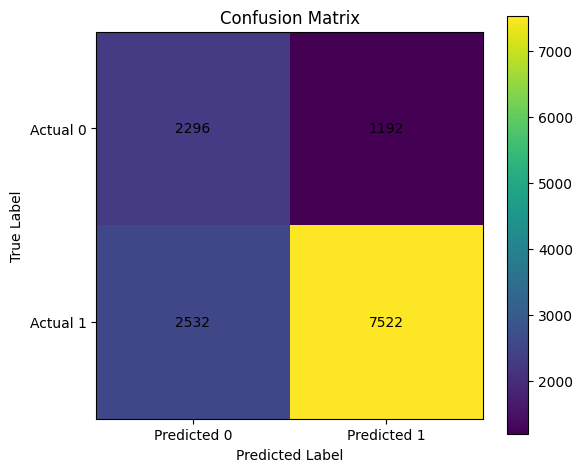

In [39]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, roc_auc_score

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n", cm)

# -----------------------------
# Plot Confusion Matrix
# -----------------------------
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0, 1], ["Predicted 0", "Predicted 1"])
plt.yticks([0, 1], ["Actual 0", "Actual 1"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [42]:
torch.save({
    "model_state_dict": model.state_dict(),
    "best_threshold": best_thr
}, "20260203_Predictive_Model_NN_trained_full_data_health_claim_model.pt")

print("✅ Model + threshold saved successfully")


✅ Model + threshold saved successfully


# Test for Unseen data 

In [41]:
def predict_unseen_health(df, model_path, batch_size=32):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    dataset = HealthDataset(df)
    loader = DataLoader(dataset, batch_size=batch_size,
                        shuffle=False, collate_fn=health_collate_fn)

    model = HealthNN(emb_dim=64).to(device)

    ckpt = torch.load(model_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    threshold = ckpt["best_threshold"]

    model.eval()

    probs, preds = [], []

    with torch.no_grad():
        for batch in loader:
            logits = model(batch)
            p = torch.sigmoid(logits)
            probs.extend(p.cpu().numpy())
            preds.extend((p >= threshold).int().cpu().numpy())

    return probs, preds


In [ ]:
probs, preds = predict_unseen_health(
    df_unseen,
    model_path="model_with_threshold.pt"
)

df_unseen["probability"] = probs
df_unseen["prediction"] = preds


In [ ]:
"""import torch

MODEL_PATH = "20260203_Predictive_Model_NN_trained_full_data.pt"

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epochs": EPOCHS
}, MODEL_PATH)

print("✅ Model saved successfully:", MODEL_PATH)"""


✅ Model saved successfully: 20260203_Predictive_Model_NN_trained_full_data.pt
